<a href="https://colab.research.google.com/github/lamini-H/Vision_Transformer/blob/main/ViT_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
#import necessary libraries
import torch
import torch.nn as nn
import torchvision
import random

In [31]:
#transformation for PIL to tensor format
#transformation_operation = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

In [32]:
#import dataset
train_dataset = torchvision.datasets.mnist.MNIST(root='./data', train=True, download=True, transform=torchvision.transforms.ToTensor())
val_dataset = torchvision.datasets.mnist.MNIST(root='./data', train=False, download=True, transform=torchvision.transforms.ToTensor())

In [33]:
from torch.nn import attention
#Define variable
num_classes = 10
batch_size = 64
num_channels =1
img_size = 28
patch_size = 7
num_patches = (img_size // patch_size) ** 2
embedding_dim = 64
attention_heads = 4
transformer_blocks = 4
mlp_hidden_nodes = 128
learning_rate = 0.001
num_epochs = 5

In [34]:
#Define dataset in batches
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size , shuffle=True)

In [35]:
# #Part 1: Patch embedding
# class PatchEmbedding(nn.Module):
#   def __init__(self):
#     super(PatchEmbedding, self).__init__()
#     self.patch_embedding = nn.Conv2d(in_channels=num_channels, out_channels=embedding_dim, kernel_size=patch_size, stride=patch_size)

#     def forward(self, x):
#       x = self.patch_embedding(x)
#       x = x.flatten(2)
#       x = x.transpose(1, 2)
#       return x

# 1. Corrected PatchEmbedding (forward method is now a proper class method)
class PatchEmbedding(nn.Module):
    def __init__(self):
        super(PatchEmbedding, self).__init__()
        self.patch_embedding = nn.Conv2d(in_channels=num_channels, out_channels=embedding_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.patch_embedding(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

In [43]:
class TransformerEncoder(nn.Module):
    def __init__(self):
        super(TransformerEncoder, self).__init__()
        self.layer_norm1 = nn.LayerNorm(embedding_dim)
        self.layer_norm2 = nn.LayerNorm(embedding_dim)
        # Fixed: Added batch_first=True so it expects (Batch, Seq, Feature)
        self.multi_head_attention = nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=attention_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim, mlp_hidden_nodes),
            nn.GELU(),
            nn.Linear(mlp_hidden_nodes, embedding_dim),
        )

    def forward(self, x):
        residual = x
        x = self.layer_norm1(x)
        x, _ = self.multi_head_attention(x, x, x)
        x = residual + x

        residual2 = x
        x = self.layer_norm2(x)
        x = self.mlp(x)
        x = x + residual2
        return x

In [42]:

# #part 3: MLP_head
# class MLP_head(nn.Module):
#   def __init__(self):
#     super(MLP_head, self).__init__()
#     self.layer_norm = nn.LayerNorm(embedding_dim)
#     self.mlp_head = nn.Linear(embedding_dim, num_classes)
#   def forward(self, x):
#     x = self.layer_norm(x)
#     x = x[:, 0]
#     x = self.mlp_head(x)


  # 2. Corrected MLP_head (added missing return statement)
class MLP_head(nn.Module):
    def __init__(self):
        super(MLP_head, self).__init__()
        self.layer_norm = nn.LayerNorm(embedding_dim)
        self.mlp_head = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp_head(x)
        return x

In [38]:
# 3. VisionTransformer wrapper integrating the corrected sub-modules
class VisionTransformer(nn.Module):
    def __init__(self):
        super(VisionTransformer, self).__init__()
        self.patch_embedding = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim))
        self.position_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embedding_dim))
        self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)])
        self.mlp_head = MLP_head()

    def forward(self, x):
        x = self.patch_embedding(x)
        B = x.size(0)
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.position_embedding
        x = self.transformer_blocks(x)
        x = x[:, 0]
        x = self.mlp_head(x)
        return x

In [44]:
# Safely move model to device after resetting runtime
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

Using device: cuda


In [45]:
print("Starting training loop...")
for epoch in range(num_epochs):
  model.train()
  total_loss = 0
  correct_epoch = 0
  total_epoch = 0
  print(f"Epoch {epoch+1}/{num_epochs}")

  for batch_idx, (images, labels) in enumerate(train_dataloader):
    images, labels = images.to(device=device), labels.to(device=device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == labels).sum().item()
    accuracy  = 100.0 * correct / labels.size(0)
    correct_epoch += correct
    total_epoch += labels.size(0)

    if (batch_idx + 1) % 100 == 0:
      print(f"Batch {batch_idx+1}/{len(train_dataloader)}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%")

    epoch_accuracy = 100.0 * correct_epoch / total_epoch
    if (batch_idx + 1) == len(train_dataloader):
      print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_dataloader):.4f}, Accuracy: {epoch_accuracy:.2f}%")

Starting training loop...
Epoch 1/5
Batch 100/938, Loss: 0.6532, Accuracy: 79.69%
Batch 200/938, Loss: 0.2594, Accuracy: 90.62%
Batch 300/938, Loss: 0.3755, Accuracy: 87.50%
Batch 400/938, Loss: 0.3818, Accuracy: 90.62%
Batch 500/938, Loss: 0.2261, Accuracy: 93.75%
Batch 600/938, Loss: 0.2935, Accuracy: 89.06%
Batch 700/938, Loss: 0.3342, Accuracy: 89.06%
Batch 800/938, Loss: 0.0885, Accuracy: 95.31%
Batch 900/938, Loss: 0.1828, Accuracy: 93.75%
Epoch 1/5, Loss: 0.3785, Accuracy: 88.02%
Epoch 2/5
Batch 100/938, Loss: 0.1862, Accuracy: 90.62%
Batch 200/938, Loss: 0.1009, Accuracy: 95.31%
Batch 300/938, Loss: 0.0985, Accuracy: 98.44%
Batch 400/938, Loss: 0.0410, Accuracy: 100.00%
Batch 500/938, Loss: 0.0988, Accuracy: 96.88%
Batch 600/938, Loss: 0.1401, Accuracy: 95.31%
Batch 700/938, Loss: 0.1025, Accuracy: 95.31%
Batch 800/938, Loss: 0.0803, Accuracy: 96.88%
Batch 900/938, Loss: 0.2008, Accuracy: 96.88%
Epoch 2/5, Loss: 0.1206, Accuracy: 96.31%
Epoch 3/5
Batch 100/938, Loss: 0.1000, Ac

In [47]:
#Evaluation mode
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images, labels in val_dataloader:
    images, labels = images.to(device=device), labels.to(device=device)
    outputs = model(images)
    preds = outputs.argmax(dim=1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)


val_accuracy = 100.0 * correct / total
print(f"\n==> Val Accuracy: {val_accuracy:.2f}%")


==> Val Accuracy: 97.84%


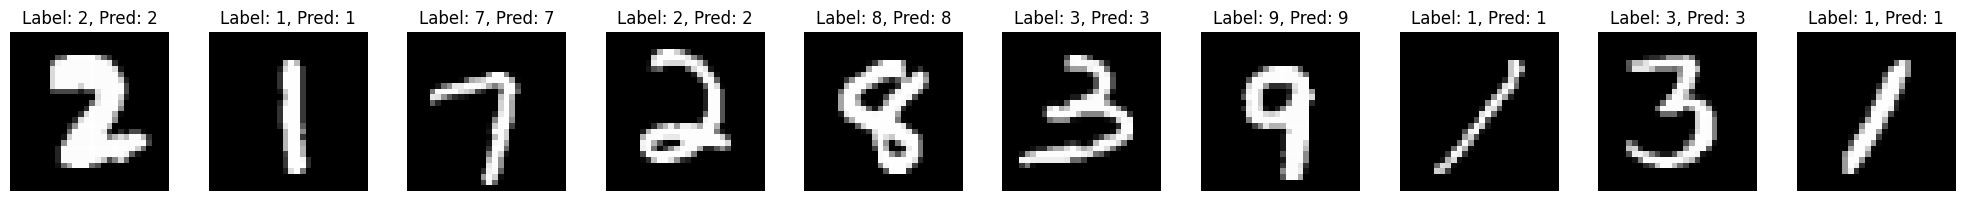

In [49]:
import matplotlib.pyplot as plt


#Show 10 predictions from the first validation batch

model.eval()
images, labels = next(iter(val_dataloader))
images, labels = images.to(device=device), labels.to(device=device)
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

#Move to CPU for plotting
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

#Plot first 10 images
fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"Label: {labels[i]}, Pred: {preds[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

